# Interactive Wingspan Notebook

This notebook contains the minimal required code for exploring the posterior model
after running the analysis in `run_analysis.py`.

In [2]:
import arviz as az

trace = az.from_netcdf("./data/results/model_posterior.nc")
trace.posterior

<xarray.Dataset> Size: 13MB
Dimensions:           (chain: 4, draw: 1000, log_eta_dim_0: 8,
                       point_categories: 8, players: 12, expansions: 4)
Coordinates:
  * chain             (chain) int64 32B 0 1 2 3
  * draw              (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * log_eta_dim_0     (log_eta_dim_0) int64 64B 0 1 2 3 4 5 6 7
  * point_categories  (point_categories) <U18 576B 'Birds' ... 'Duet Tokens'
  * players           (players) <U7 336B 'A' 'B' 'Camille' ... 'T' 'Yizhou'
  * expansions        (expansions) <U7 112B 'All' 'Asia' 'Europe' 'Oceania'
Data variables:
    log_eta           (chain, draw, log_eta_dim_0) float32 128kB ...
    phi               (chain, draw, point_categories) float32 128kB ...
    point_eps         (chain, draw) float32 16kB ...
    point_mean        (chain, draw) float32 16kB ...
    point_sigma       (chain, draw) float32 16kB ...
    points_category   (chain, draw, players, expansions, point_categories) float32 6MB ...
    points_total      (chain, draw, players, expansions) float32 768kB ...
    theta             (chain, draw, players, expansions, point_categories) float32 6MB ...
Attributes:
    created_at:                 2025-09-21T21:48:29.511980+00:00
    arviz_version:              0.22.0
    inference_library:          numpyro
    inference_library_version:  0.19.0

It's impossible to know ahead of time all the questions you may want to explore on this particular model, and for that reason, this notebook provides a place to explore the fitted posterior you get after running the entire analysis. For example, "what's the probability that Matt wins a particular game in total points against Camille for each expansion?"

In [14]:
total_point_set = trace.posterior["points_total"]
(total_point_set.sel(players="Matt") > total_point_set.sel(players="Camille")).mean(
    axis=(0, 1)
)

<xarray.DataArray 'points_total' (expansions: 4)> Size: 32B
array([0.95575, 0.881  , 1.     , 0.98675])
Coordinates:
  * expansions  (expansions) <U7 112B 'All' 'Asia' 'Europe' 'Oceania'

Forest plots and ridge plots provide a way to visualize the posterior distributions across multiple dimensions. An example is included here. This was the method used to create the plots in `data/results/figures`.

Here is an example - notice the variance on Sam's parameters. Since he's only played one game in our dataset, he basically gets the hierarchical dataset except in the one expansion he actually played.

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

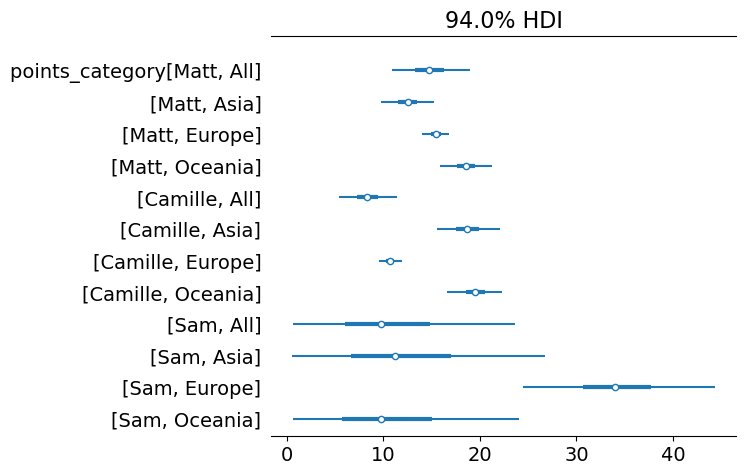

In [16]:
# predict points within categories
az.plot_forest(
    trace,
    var_names=["points_category"],
    coords={
        "point_categories": ["Tucked Cards"],
        "players": ["Matt", "Camille", "Sam"],
    },
    combined=True,
)